<a href="https://colab.research.google.com/github/manan36chauhan/data_science_project/blob/First-init/myml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import pandas as pd
df = pd.read_csv('/content/adult.csv')
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [2]:
df.shape

(32561, 15)

In [3]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  target          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
df.describe(include='all')

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
count,32561.000000,32561,3.256100e+04,32561,32561.000000,32561,32561,32561,32561,32561,32561.000000,32561.000000,32561.000000,32561,32561
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.581647,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,1077.648844,87.303830,40.437456,NaN,NaN
std,13.640433,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,7385.292085,402.960219,12.347429,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


In [6]:
(df == '?').sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


In [8]:
cat_columns = df.select_dtypes(include='object').columns
cat_columns

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'target'],
      dtype='object')

In [9]:
label_encoders = {}
for column in cat_columns:
  df[column] = df[column].str.strip()
  le = LabelEncoder()
  df[column] = le.fit_transform(df[column])
  label_encoders[column] = le


In [10]:
df.dtypes

,0
age,int64
workclass,int64
fnlwgt,int64
education,int64
education-num,int64
marital-status,int64
occupation,int64
relationship,int64
race,int64
sex,int64


In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X = df.drop('target', axis=1)
y = df['target']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(26048, 14)
(6513, 14)
(26048,)
(6513,)


In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [16]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [17]:
df.select_dtypes(include='object').columns


Index([], dtype='object')

In [18]:
y_pred = model.predict(X_test)

In [19]:
print("Accuracy", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy 0.810379241516966
              precision    recall  f1-score   support

           0       0.88      0.87      0.87      4942
           1       0.60      0.63      0.62      1571

    accuracy                           0.81      6513
   macro avg       0.74      0.75      0.75      6513
weighted avg       0.81      0.81      0.81      6513



In [20]:
from sklearn.ensemble import RandomForestClassifier

In [21]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [22]:
rf_pred = rf_model.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score,classification_report
print("Rando, Forest Accuracy", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Rando, Forest Accuracy 0.8616612927990174
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4942
           1       0.75      0.64      0.69      1571

    accuracy                           0.86      6513
   macro avg       0.82      0.79      0.80      6513
weighted avg       0.86      0.86      0.86      6513



# **Logistic Regression**

In [24]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [25]:
log_pred = log_model.predict(X_test)
print("Logistic Regression Accuracy", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy 0.7899585444495624
              precision    recall  f1-score   support

           0       0.81      0.94      0.87      4942
           1       0.64      0.30      0.41      1571

    accuracy                           0.79      6513
   macro avg       0.72      0.62      0.64      6513
weighted avg       0.77      0.79      0.76      6513



# KNN

In [26]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [27]:
knn_pred = knn_model.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))


KNN Accuracy: 0.7785966528481498
              precision    recall  f1-score   support

           0       0.81      0.92      0.86      4942
           1       0.57      0.33      0.42      1571

    accuracy                           0.78      6513
   macro avg       0.69      0.62      0.64      6513
weighted avg       0.75      0.78      0.76      6513



In [28]:
import joblib
joblib.dump(model, 'adult_income_model.pkl')

['adult_income_model.pkl']

In [29]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier


model = RandomForestClassifier(random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.65349144 0.67795176 0.66961131 0.67713787 0.69864806]
Mean accuracy: 0.6753680859857571


In [30]:
X_train_dropped = X_train.drop(columns=['fnlwgt', 'education-num', 'capital-gain', 'capital-loss'])

In [31]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_dropped, y_train)

RandomForestClassifier(random_state=42)

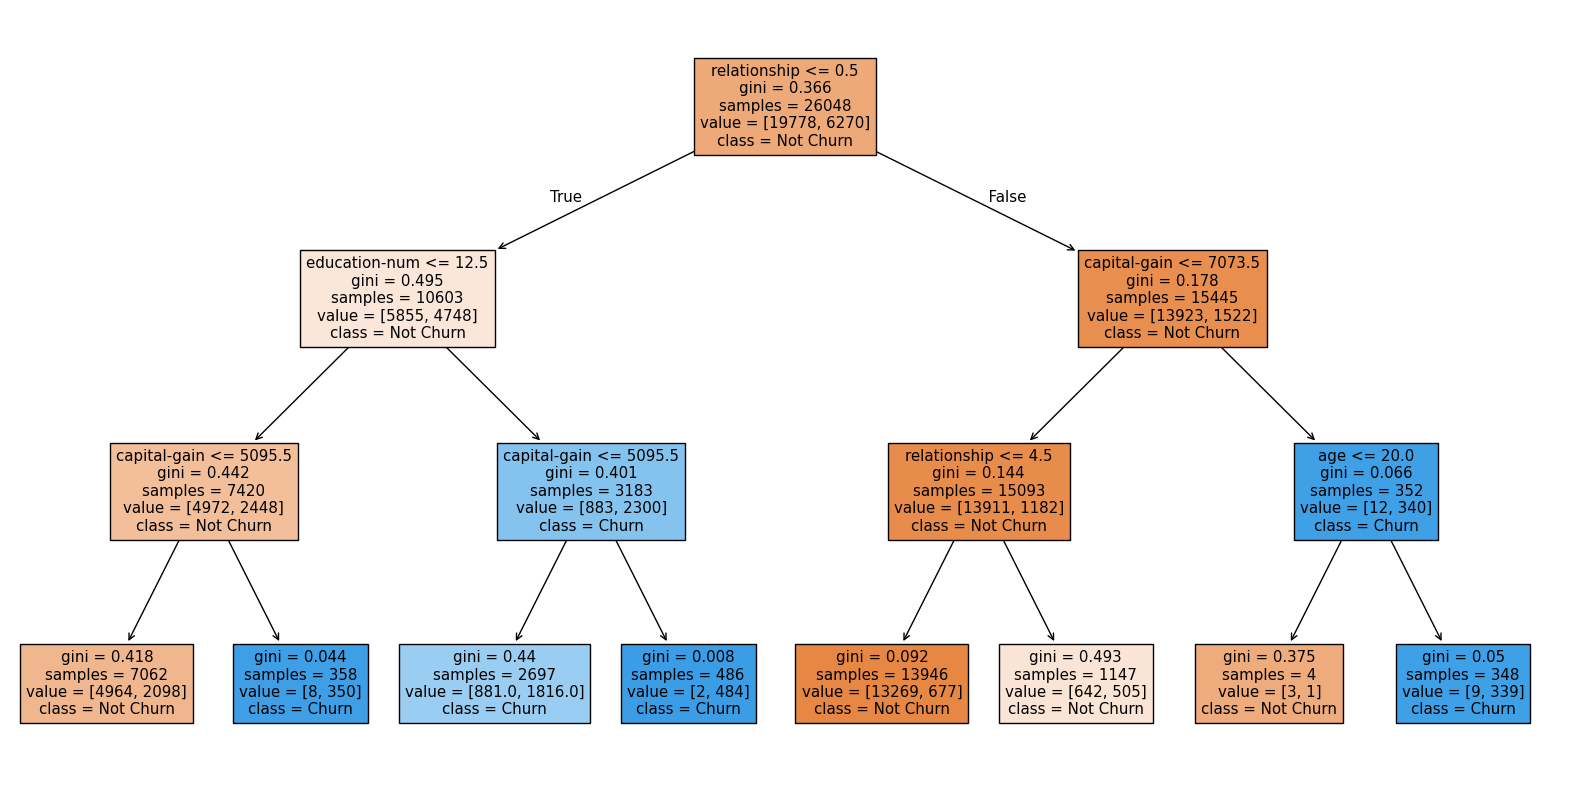

In [32]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X_train.columns, class_names=['Not Churn', 'Churn'], filled=True)
plt.show()


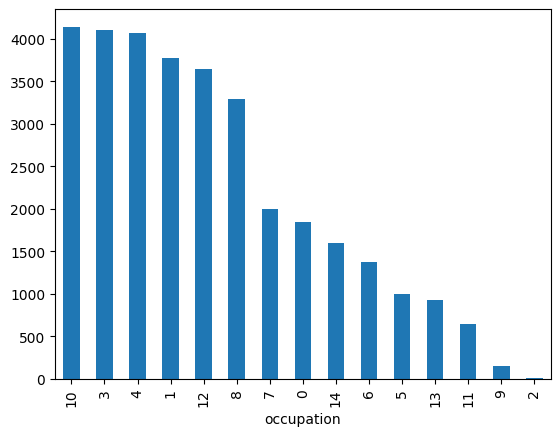

In [47]:
df['occupation'].value_counts().plot(kind='bar')
plt.show()

In [49]:
#sns.pairplot(df)
#plt.show()

In [54]:
df.replace(' ?', pd.NA, inplace=True)
print(df.isna().sum())


age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
target            0
dtype: int64


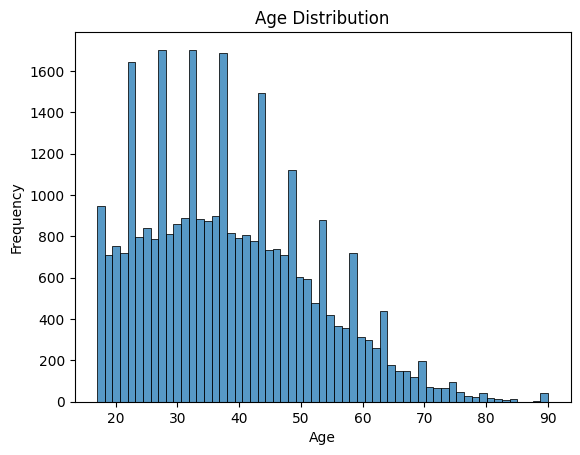

In [64]:
sns.histplot(df['age'])
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [66]:
df['target'].unique()

array([' <=50K', ' >50K'], dtype=object)

In [67]:
df['income'] = df['target'].map({0: '<=50K', 1: '>50K'})

In [82]:
avg_age = df.groupby('income')['age'].mean()
df['income'] = df['target'].str.strip()
print(df['income'].unique())
print(df['income'].value_counts(dropna=False))

['<=50K' '>50K']
income
<=50K    24720
>50K      7841
Name: count, dtype: int64


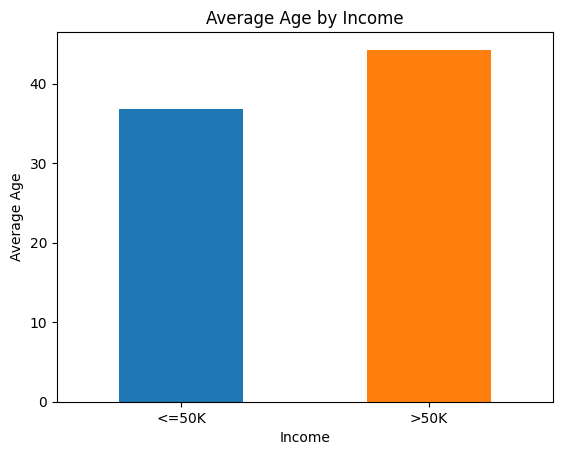

In [81]:
avg_age = df.groupby('income')['age'].mean()
avg_age

colors = ['#1f77b4', '#ff7f0e']
avg_age.plot(kind='bar', color=colors)
plt.title('Average Age by Income')
plt.xlabel('Income')
plt.ylabel('Average Age')
plt.xticks(rotation=0)
plt.show()


education
Bachelors       2221
HS-grad         1675
Some-college    1387
Masters          959
Prof-school      423
Assoc-voc        361
Doctorate        306
Assoc-acdm       265
10th              62
11th              60
7th-8th           40
12th              33
9th               27
5th-6th           16
1st-4th            6
Name: count, dtype: int64


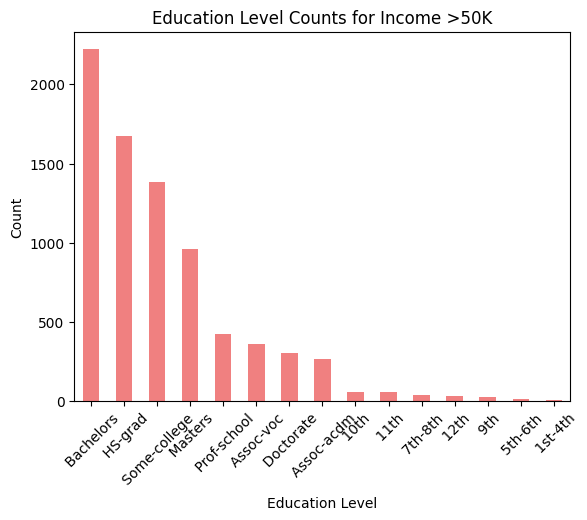

In [86]:
high_income_df = df[df['income'] == '>50K']
low_income_df = df[df['income'] == '<=50K']
education_counts = high_income_df['education'].value_counts()
education_counts_low = low_income_df['education'].value_counts()
print(education_counts)

education_counts.plot(kind='bar', color='lightcoral')
plt.title('Education Level Counts for Income >50K')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

income  <=50K  >50K
sex                
Female   9592  1179
Male    15128  6662


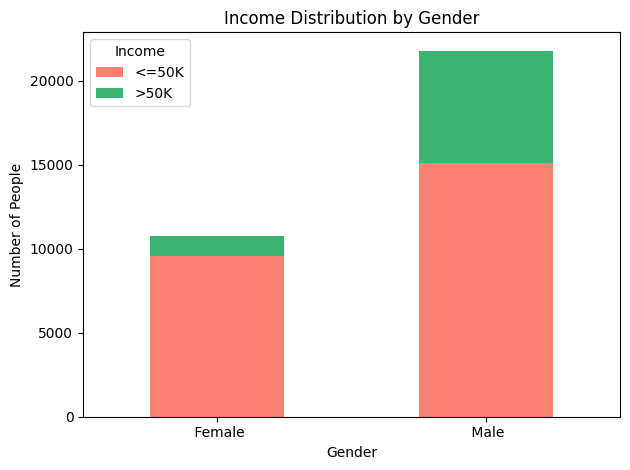

In [89]:
gender_income = df.groupby(['sex', 'income']).size().unstack()
print(gender_income)


gender_income.plot(kind='bar', stacked=True, color=['salmon', 'mediumseagreen'])
plt.title('Income Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of People')
plt.xticks(rotation=0)
plt.legend(title='Income')
plt.tight_layout()
plt.show()
